In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import basedir

model = "EGFR_MAPK__logobs_tegfr_aggavg"
data = "dream_cytof"

evaluations_dir_her2 = basedir / "eval_p38_v2"
evaluations_dir_noher2 = basedir / "eval_p38_noher2"

filename = "evaluate_all_figure5.csv"

df_her2 = pd.read_csv(evaluations_dir_her2 / model / data / filename, index_col=0).assign(her2=True)
df_noher2 = pd.read_csv(evaluations_dir_noher2 / model / data / filename, index_col=0).assign(her2=False)

df = pd.concat([df_her2, df_noher2])
df.model.fillna(model, inplace=True)  # single model investigated in this batch of runs

In [2]:
train_df = df[df.dataset == "train"]
train_df.features.fillna("None", inplace=True)

val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [3]:
val_df.groupby(["ref", "model", "context", "features", "her2", "samples"]).rmse.mean()

ref     model                           context     features        her2   samples 
DMM     EGFR_MAPK__logobs_tegfr_aggavg  cytof_init  RFE_15_permute  False  184A1       0.442251
                                                                           184B5       0.576582
                                                                           AU565       0.609452
                                                                           BT20        0.501514
                                                                           BT474       0.528586
                                                                                         ...   
sample  EGFR_MAPK__logobs_tegfr_aggavg  multimodal  None            True   UACC3199    0.376904
                                                                           UACC812     0.238494
                                                                           UACC893     0.216175
                                                    

In [4]:
dmm_df = df[df.ref == "DMM"]

# At first glance, removing HER2 hurts performance

In [5]:
val_df[val_df.ref == "DMM"].groupby(["context", "her2"]).rmse.mean()

context     her2 
cytof_init  False    0.506571
            True     0.472385
multimodal  False    0.511151
            True     0.491631
Name: rmse, dtype: float64

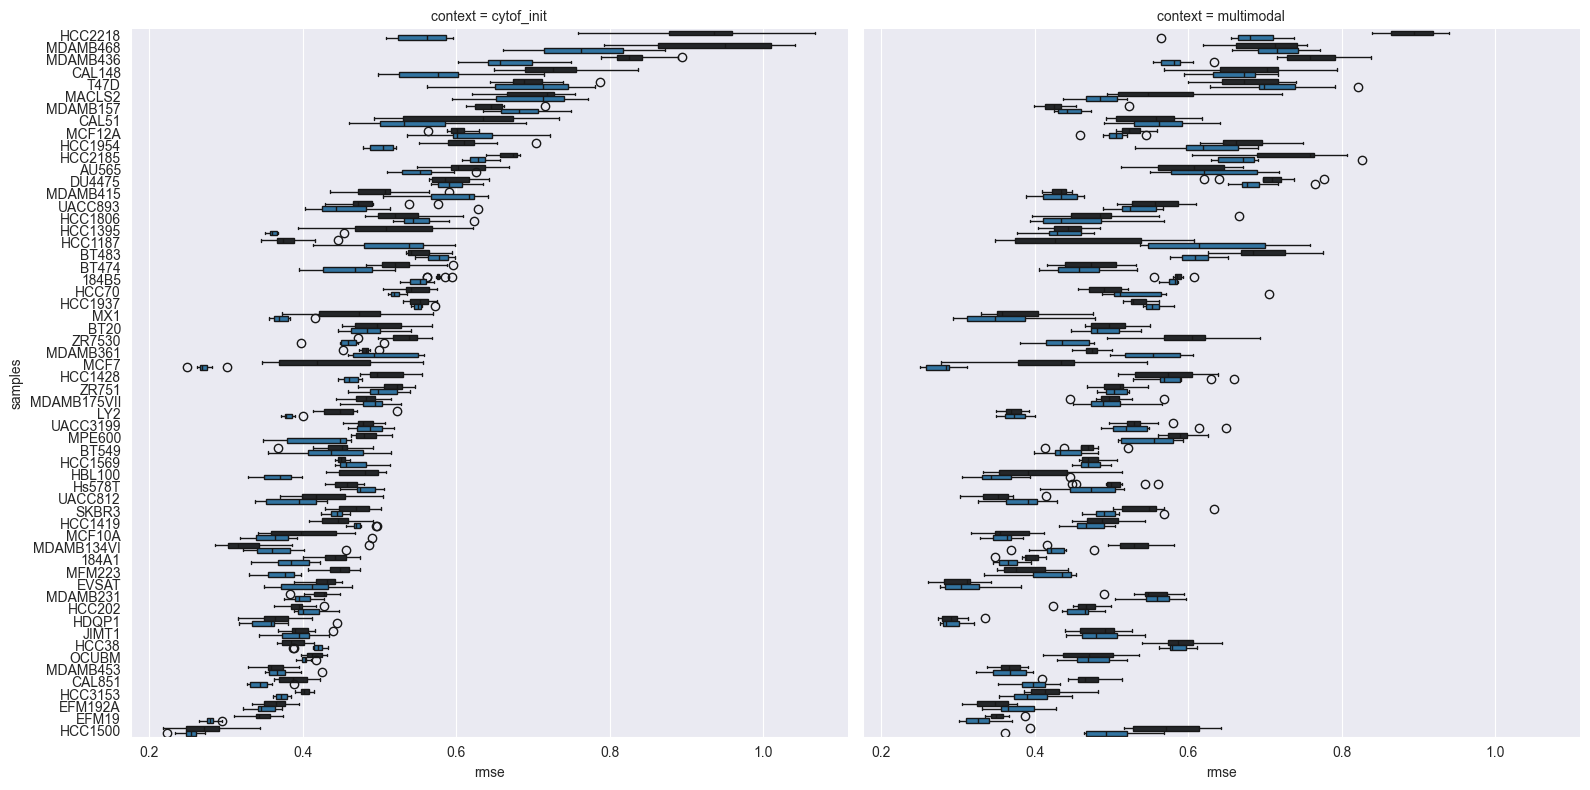

In [6]:
g = sns.FacetGrid(
    dmm_df[dmm_df.dataset == "val"].sort_values(by="rmse", ascending=False),
    col="context",
    col_order=["cytof_init", "multimodal"],
    height=8
)

g.map_dataframe(
    sns.boxplot,
    x="rmse",
    y="samples",
    hue="her2",
)

# We can dig deeper and ask: which cell-lines does removing HER2 hurt/not hurt performance?

In [7]:
# Load the per-cell-line/condition/observable RMSE dataset
by_df_her2 = pd.read_csv(evaluations_dir_her2 / model / data / "by_cl_cond_obs_figure5.csv").assign(her2=True)
by_df_noher2 = pd.read_csv(evaluations_dir_noher2 / model / data / "by_cl_cond_obs_figure5.csv").assign(her2=False)
by_df = pd.concat([by_df_her2, by_df_noher2])

# Basic cleaning
by_df = by_df.rename(columns={"samples": "cell_line"})

# Ensure dataset column has "train" and "val"
assert set(by_df["dataset"].unique()) <= {"train", "val"}

# -------------------------------------------------------------------
# 1. Compute RMSE_seen and RMSE_unseen per cell-line and context
# -------------------------------------------------------------------
agg = (
    by_df
    .groupby(["cell_line", "context", "dataset", "her2"])
    .agg(mean_rmse=("rmse", "mean"))
    .reset_index()
)

# Pivot so we get columns: train_rmse, val_rmse
pivot = (
    agg
    .pivot_table(
        index=["cell_line", "context", "her2"],
        columns="dataset",
        values="mean_rmse"
    )
    .reset_index()
    .rename(columns={"train": "rmse_seen", "val": "rmse_unseen"})
)

# Compute generalisation gap
pivot["generalisation_gap"] = pivot["rmse_unseen"] - pivot["rmse_seen"]

print("\n=== Per-cell-line generalisation gap (using only by_cl_cond_obs_figure5.csv) ===")
print(pivot.sort_values("generalisation_gap", ascending=False))


=== Per-cell-line generalisation gap (using only by_cl_cond_obs_figure5.csv) ===
dataset cell_line     context   her2  rmse_seen  rmse_unseen  \
184      MDAMB468  cytof_init  False   0.357714     0.737346   
106       HCC2218  multimodal  False   0.323296     0.699140   
145        MCF12A  cytof_init   True   0.353793     0.728721   
211          T47D  multimodal   True   0.346471     0.716783   
210          T47D  multimodal  False   0.351149     0.697730   
..            ...         ...    ...        ...          ...   
123         HDQP1  multimodal   True   0.329995     0.286066   
122         HDQP1  multimodal  False   0.337586     0.292751   
57         HBL100  cytof_init   True   0.359224     0.313331   
48        EFM192A  cytof_init  False   0.360199     0.312845   
49        EFM192A  cytof_init   True   0.346565     0.297216   

dataset  generalisation_gap  
184                0.379632  
106                0.375845  
145                0.374927  
211                0.370312  

In [8]:
pivot[pivot.context == "cytof_init"].sort_values(by="generalisation_gap", ascending=False)

dataset,cell_line,context,her2,rmse_seen,rmse_unseen,generalisation_gap
184,MDAMB468,cytof_init,False,0.357714,0.737346,0.379632
145,MCF12A,cytof_init,True,0.353793,0.728721,0.374927
144,MCF12A,cytof_init,False,0.365024,0.706788,0.341765
104,HCC2218,cytof_init,False,0.344458,0.676233,0.331774
209,T47D,cytof_init,True,0.373421,0.702548,0.329126
...,...,...,...,...,...,...
133,LY2,cytof_init,True,0.383415,0.347139,-0.036276
121,HDQP1,cytof_init,True,0.346179,0.309087,-0.037092
57,HBL100,cytof_init,True,0.359224,0.313331,-0.045894
48,EFM192A,cytof_init,False,0.360199,0.312845,-0.047354


In [9]:
pivot[pivot.context == "multimodal"].sort_values(by="generalisation_gap", ascending=False)

dataset,cell_line,context,her2,rmse_seen,rmse_unseen,generalisation_gap
106,HCC2218,multimodal,False,0.323296,0.699140,0.375845
211,T47D,multimodal,True,0.346471,0.716783,0.370312
210,T47D,multimodal,False,0.351149,0.697730,0.346580
102,HCC2185,multimodal,False,0.339411,0.671118,0.331706
146,MCF12A,multimodal,False,0.343648,0.658420,0.314772
...,...,...,...,...,...,...
218,UACC812,multimodal,False,0.337872,0.321896,-0.015977
50,EFM192A,multimodal,False,0.337038,0.319155,-0.017883
59,HBL100,multimodal,True,0.337326,0.314897,-0.022429
123,HDQP1,multimodal,True,0.329995,0.286066,-0.043929


In [10]:
pivot.groupby(["context", "her2"]).generalisation_gap.mean()

context     her2 
cytof_init  False    0.107836
            True     0.093987
multimodal  False    0.136496
            True     0.128967
Name: generalisation_gap, dtype: float64

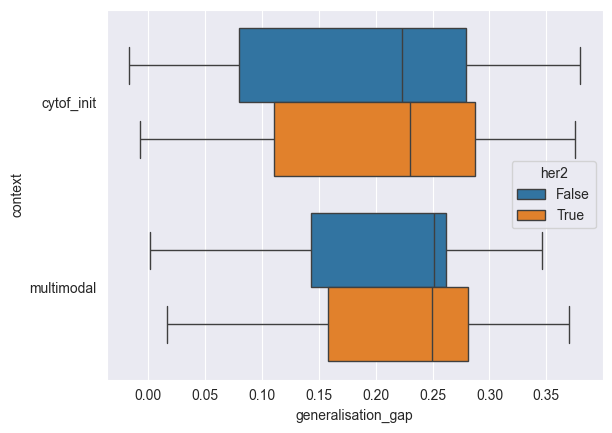

<Axes: xlabel='generalisation_gap', ylabel='context'>

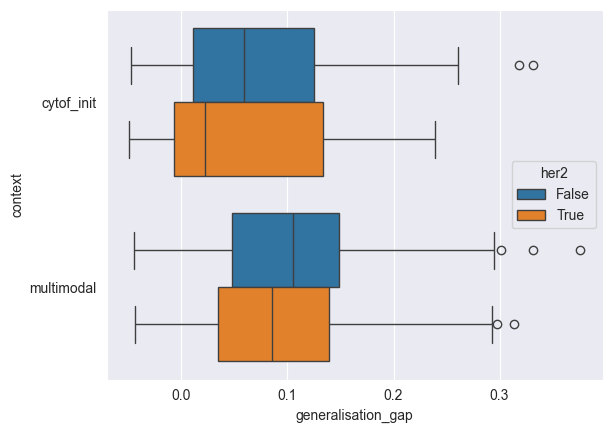

In [11]:
missing_erbb2_cell_lines = {
    "cBT483", "cHCC1187", "cHCC1419", "cHCC1569", "cHCC1806", "cHCC1937", "cHCC70", "cMCF12A", "cMDAMB231",
    "cMDAMB361", "cMDAMB453", "cMDAMB468", "cT47D", "cUACC893"
}

missing_erbb2_cell_lines = [cell_line[1:] for cell_line in missing_erbb2_cell_lines]


sns.boxplot(
    pivot[pivot.cell_line.isin(missing_erbb2_cell_lines)],
    x="generalisation_gap",
    y="context",
    hue="her2",
)
plt.show()

sns.boxplot(
    pivot[~pivot.cell_line.isin(missing_erbb2_cell_lines)],
    x="generalisation_gap",
    y="context",
    hue="her2",
)

## Lower generalisation gap (marginally) if removing HER2 for cell-lines that lack HER2 measurements

In [12]:
pivot[pivot.cell_line.isin(missing_erbb2_cell_lines)].groupby(["context", "her2"]).generalisation_gap.mean()

context     her2 
cytof_init  False    0.190257
            True     0.197524
multimodal  False    0.209583
            True     0.222867
Name: generalisation_gap, dtype: float64

## Substantially higher generalisation gap if removing HER2 for cell-lines that do have HER2 measurements

In [13]:
pivot[~pivot.cell_line.isin(missing_erbb2_cell_lines)].groupby(["context", "her2"]).generalisation_gap.mean()

context     her2 
cytof_init  False    0.081611
            True     0.061043
multimodal  False    0.113241
            True     0.099090
Name: generalisation_gap, dtype: float64

# Interestingly, for cell-lines which do have p.HER2 data, having p.HER2 in feature set helps - both statistically significantly (Wilcoxon signed rank test). For those that do not, not having it helps = imputation hurts (but effect is much smaller than the previous one).

In [14]:
from scipy import stats

target_metric = "rmse"
groups = [
    pivot[(pivot.cell_line.isin(missing_erbb2_cell_lines)) & (pivot.her2)].sort_values(by=["cell_line"]).generalisation_gap.values,
    pivot[(pivot.cell_line.isin(missing_erbb2_cell_lines)) & (~pivot.her2)].sort_values(by=["cell_line"]).generalisation_gap.values,
]
stat, p = stats.wilcoxon(*groups, alternative="greater")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=292.0, p=0.0213


In [15]:
from scipy import stats

target_metric = "rmse"
groups = [
    pivot[~(pivot.cell_line.isin(missing_erbb2_cell_lines)) & (pivot.her2)].sort_values(by=["cell_line"]).generalisation_gap.values,
    pivot[~(pivot.cell_line.isin(missing_erbb2_cell_lines)) & (~pivot.her2)].sort_values(by=["cell_line"]).generalisation_gap.values,
]
stat, p = stats.wilcoxon(*groups, alternative="less")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=1054.0, p=8.448e-05


# Can RFE figure out that adding p.HER2 would help?

In [16]:
from dmm.feature_selection import build_preprocessor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from typing import Union


def get_feature_importances(model, X, y, method="auto"):
    """
    Get feature importances for RandomForest or ElasticNet/LogisticRegression models.

    Parameters:
    - model: fitted sklearn model
    - method: 'auto', 'coef', 'tree', 'permutation'
    - X: input features (optional, needed for permutation importance)
    - y: target variable (optional, needed for permutation importance)

    Returns:
    - feature_importances: np.ndarray of shape (n_features,)
    """
    if method == "tree":
        return model.named_steps["regressor"].feature_importances_

    elif method == "permute":
        if X is None or y is None:
            raise ValueError(
                "X and y must be provided for permutation importance."
            )
        result = permutation_importance(
            model, X, y, n_repeats=10, random_state=42
        )
        return result.importances_mean

    else:
        raise ValueError(f"Unknown method: {method}")


def get_hvg(input_df: pd.DataFrame, top_n: Union[int, float] = 500) -> pd.DataFrame:
    # remove 20% of features with the lowest mean:
    means = np.mean(input_df, axis=0)
    threshold = np.percentile(means, 20)
    input_df = input_df.loc[:, means >= threshold]
    if isinstance(top_n, int):
        # Keep top N features with the highest variance
        var_threshold = sorted(
            np.nanvar(input_df, axis=0), reverse=True
        )[top_n]
        input_df = input_df.loc[
                     :, np.nanvar(input_df, axis=0) >= var_threshold
                     ]
    elif isinstance(top_n, float):
        perc = 100 * top_n
        # Keep top 50% features with the highest variance (default)
        var_threshold = np.percentile(np.nanvar(input_df, axis=0), perc)
        input_df = input_df.loc[
                     :, np.nanvar(input_df, axis=0) >= var_threshold
                     ]
    return input_df


def get_selected_features(
    input_data,
    output_data,
    context: str,
    features: str,
    features_all: list,
    cv=None,
):
    if features == "all":
        return features_all

    if features.startswith("RFE_") or features.startswith("HVGRFE_"):
        reduce_factor = 0.80
        # drop nans, this shouldnt do anything
        input_data = input_data.dropna(axis=1, how="any")
        if features.startswith("HVG") and context in [
            "proteomics",
            "transcriptomics",
        ]:
            input_data = get_hvg(input_data)

        output_data -= output_data.mean(axis=0)  # center output data

        n_features = int(features.split("_")[1])
        method = features.split("_")[2]
        random_state = 42  # For reproducibility
        estimator = RandomForestRegressor(
            random_state=random_state,
            max_features=reduce_factor,
        )
        pipeline = Pipeline(
            [("scaler", StandardScaler()), ("regressor", estimator)]
        )
        while input_data.shape[1] * reduce_factor > n_features:
            pipeline = pipeline.fit(input_data, output_data)
            y_pred = pipeline.predict(input_data)
            rmse = np.sqrt(np.mean(np.square(output_data.values - y_pred)))
            importances = get_feature_importances(
                pipeline,
                input_data,
                output_data,
                method=method if input_data.shape[1] <= 500 else "tree",
            )

            n_features_target = int(np.ceil(len(importances) * reduce_factor))
            if n_features_target == input_data.shape[1]:
                n_features_target -= 1  # reduce by at least one feature
            indices = np.argsort(importances)[::-1][:n_features_target]
            input_data = input_data.iloc[:, indices]
            print(
                f"Reduced features to: {input_data.shape[1]:>5} ({rmse:.2f})",
            )
        # Fit the final model with the selected features
        pipeline = pipeline.fit(input_data, output_data)
        importances = get_feature_importances(
            pipeline, input_data, output_data, method=method
        )
        indices = np.argsort(importances)[::-1][:n_features]
        return input_data.columns[indices]

    preprocessor = build_preprocessor(features, input_data, output_data, cv=cv)
    preprocessor = preprocessor.fit(input_data, output_data)

    return preprocessor.feature_names_in_[
        preprocessor.steps[-1][1].get_support()
    ]

In [50]:
def build_targets_df(
    by_df: pd.DataFrame,
    cytof_init: pd.DataFrame,
    context: str = "cytof_init",
    metric: str = "unseen",
) -> pd.DataFrame:
    """
    Build a multi-task regression target matrix.

    Rows   = cell-lines (aligned with cytof_init.index)
    Cols   = all (condition, observable) pairs for the chosen context
    Values = chosen metric per (cell-line, condition, observable):
             - "unseen": RMSE on dataset == "val"
             - "seen"  : RMSE on dataset == "train"
             - "gap"   : RMSE_unseen - RMSE_seen
    """
    df = by_df.copy()

    # Restrict to the desired context (cytof_init vs multimodal)
    df = df[df["context"] == context]

     # Ensure consistent index
    # df = df.rename(columns={"samples": "cell_line"})
    df.drop(columns=["Unnamed: 0"], inplace=True)

    # Aggregate over jobs, replicates, etc. for stability
    df_agg = (
        df.groupby(["context", "cell_line", "condition", "observable", "dataset", "her2"], as_index=False)
          .agg(mean_rmse=("rmse", "mean"))
    )

    # Pivot dataset -> train/val columns
    pivot = df_agg.pivot_table(
        index=["context", "cell_line", "condition", "observable", "her2"],
        columns="dataset",
        values="mean_rmse",
    ).reset_index()

    # Rename columns for clarity; some combos may be missing train/val
    pivot = pivot.rename(columns={"train": "rmse_seen", "val": "rmse_unseen"})

    # We only want rows where both seen and unseen exist (for "gap"),
    # but for "seen" or "unseen" you could relax this if you like.
    if metric == "gap":
        pivot = pivot.dropna(subset=["rmse_seen", "rmse_unseen"])

    # Choose the target metric
    if metric == "unseen":
        pivot["target"] = pivot["rmse_unseen"]
    elif metric == "seen":
        pivot["target"] = pivot["rmse_seen"]
    elif metric == "gap":
        pivot["target"] = pivot["rmse_unseen"] - pivot["rmse_seen"]
    else:
        raise ValueError(f"Unknown metric: {metric!r} (use 'unseen', 'seen', or 'gap')")

    # Wide format: one row per cell-line, one column per (condition, observable)
    wide = pivot.pivot_table(
        index="cell_line",
        columns=["condition", "observable"],
        values="target",
    )

    wide.sort_index(inplace=True)

    # Flatten MultiIndex columns: e.g. "EGF_10ng__pERK"
    wide.columns = [
        f"{cond}__{obs}"
        for (cond, obs) in wide.columns.to_list()
    ]

    # Align cell-lines between cytof_init and the targets
    # (assuming cytof_init index are cell-line names)
    cytof_init = cytof_init.reset_index()
    cytof_init.preequilibrationConditionId = cytof_init.preequilibrationConditionId.apply(lambda x: x[1:])
    cytof_init.set_index("preequilibrationConditionId", inplace=True)
    cytof_init.sort_index(inplace=True)

    cell_lines_inputs = set(cytof_init.index)
    cell_lines_targets = set(wide.index)
    common_cell_lines = sorted(cell_lines_inputs & cell_lines_targets)

    # Subset & align
    targets_df = wide.loc[common_cell_lines].sort_index()
    # You’ll want your X to be aligned too:
    inputs_aligned = cytof_init.loc[common_cell_lines].sort_index()

    return inputs_aligned, targets_df

In [59]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs_tegfr_aggavg", data="dream_cytof"))
del petab_base_files["condition_table"]
samples = get_samples("dream_cytof")

cytof_init, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)

# Restrict to noHER2 & cell-lines with non-NaN pERBB2 data
X_inputs, Y_targets = build_targets_df(
    by_df=by_df[(~by_df.her2) & (~by_df.cell_line.isin(missing_erbb2_cell_lines))],  # Restrict to noHER2 & cell-lines with non-NaN pERBB2 data
    cytof_init=cytof_init,
    context="cytof_init",   # or "multimodal"
    metric="gap",           # "unseen", "seen", or "gap"
)

selected_markers = get_selected_features(
    input_data=X_inputs.sort_index(),
    output_data=Y_targets.sort_index().dropna(axis=1),
    context="cytof_init",
    features="RFE_10_permute",
    features_all=None
)

print(selected_markers)

44
Reduced features to:    30 (0.07)
Reduced features to:    24 (0.07)
Reduced features to:    20 (0.07)
Reduced features to:    16 (0.07)
Reduced features to:    13 (0.07)
Reduced features to:    11 (0.07)
Index(['p.4EBP1', 'p.S6K', 'cleavedCas', 'p.RB', 'p.HER2', 'p.AKT.Thr308.',
       'p.p38', 'p.STAT5', 'p.S6', 'p.p53'],
      dtype='object')


In [60]:
# Restrict to noHER2, cell-lines with non-NaN pERBB2 data & only pERBB2 residuals/generalisation gap
selected_markers = get_selected_features(
    input_data=X_inputs.sort_index(),
    output_data=Y_targets[[col for col in Y_targets.columns if "pERBB2" in col]].sort_index().dropna(axis=1),
    context="cytof_init",
    features="RFE_10_permute",
    features_all=None
)
print(selected_markers)

Reduced features to:    30 (0.10)
Reduced features to:    24 (0.09)
Reduced features to:    20 (0.09)
Reduced features to:    16 (0.09)
Reduced features to:    13 (0.09)
Reduced features to:    11 (0.09)
Index(['cleavedCas', 'p.RB', 'p.4EBP1', 'p.ERK', 'p.HER2', 'p.p53',
       'p.AKT.Thr308.', 'p.MKK4', 'p.SRC', 'p.NFkB'],
      dtype='object')


In [63]:
[col for col in Y_targets.columns if "pERBB2" in col]

['EGF__pERBB2_Y1248_obs', 'iEGFR__pERBB2_Y1248_obs', 'iMEK__pERBB2_Y1248_obs']

In [79]:
Y_targets.sort_index()["EGF__pERBB2_Y1248_obs"]

cell_line
184A1         -0.069275
184B5          0.016015
AU565          0.021323
BT20           0.495352
BT474          0.115028
BT549         -0.100489
CAL148         0.481185
CAL51         -0.179749
CAL851         0.013189
DU4475         0.039213
EFM19          0.023222
EFM192A       -0.216470
EVSAT          0.092131
HBL100         0.094844
HCC1395       -0.049991
HCC1428       -0.105326
HCC1500       -0.030682
HCC1954        0.579855
HCC202         0.166497
HCC2185        0.369996
HCC2218        1.164823
HCC3153       -0.052065
HCC38         -0.173945
HDQP1         -0.169479
Hs578T         0.051250
JIMT1         -0.057227
LY2            0.146502
MACLS2         0.147483
MCF10A         0.049492
MCF7           0.336035
MDAMB134VI     0.114398
MDAMB157       0.151584
MDAMB175VII    0.121724
MDAMB415      -0.013816
MDAMB436       0.611268
MFM223         0.090185
MPE600         0.360647
MX1            0.159999
OCUBM         -0.176373
SKBR3         -0.097644
UACC3199       0.030087
UACC81

<Axes: xlabel='iMEK__pERBB2_Y1248_obs', ylabel='EGF__pERBB2_Y1248_obs'>

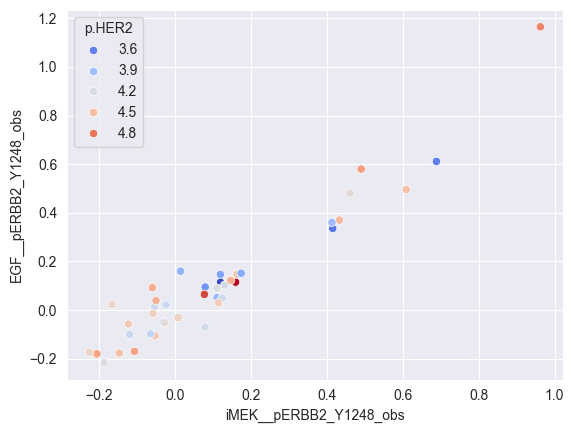

In [84]:
sns.scatterplot(
    x=Y_targets.sort_index()["iMEK__pERBB2_Y1248_obs"],
    y=Y_targets.sort_index()["EGF__pERBB2_Y1248_obs"],
    hue=X_inputs.sort_index()["p.HER2"],
    palette="coolwarm"
)

## Unfortunately, it cannot. p.HER2 only appears as 28th when selecting 30 features out of 37...It can find p.HER2 among top 5 features if we restrict the analysis to noHER2-feature & cell-lines that are hurt by lack of p.HER2 features, i.e. those that have non-NaN p.HER2 measurements! (both all observables and pERBB2 observables only) But cannot rationalise easily by plotting generalisation gap vs p.HER2 or using p.HER2 as hue in generalisation gap among two marker/condition combos.

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_residuals(model, context, gap_threshold=0.0,
                   metric="euclidean", method="average", have_her2=True):
    """
    Clustermap of per-cell-line generalisation gap, clustered on the gap.

    Parameters
    ----------
    model : str
        Model name (used with evaluations_dir / model / "data").
    context : str
        Biological context to filter on.
    gap_threshold : float, optional
        Keep only cell lines whose max |gap| across (condition, observable)
        exceeds this value. Set to 0.0 to keep all.
    metric : str, optional
        Distance metric for clustermap (rows).
    method : str, optional
        Linkage method for clustermap.
    """

    # ----------------------------------------------------------------------
    # Load and basic cleaning
    # ----------------------------------------------------------------------
    by_df = pd.read_csv(evaluations_dir_noher2 / model / data / "by_cl_cond_obs_figure5.csv").assign(her2=False)

    if "samples" in by_df.columns and "cell_line" not in by_df.columns:
        by_df = by_df.rename(columns={"samples": "cell_line"})
    if have_her2:
        by_df = by_df[~by_df.cell_line.isin(missing_erbb2_cell_lines)]
    else:
        by_df = by_df[by_df.cell_line.isin(missing_erbb2_cell_lines)]

    required_cols = {"cell_line", "context", "dataset", "condition", "observable", "rmse"}
    missing = required_cols - set(by_df.columns)
    if missing:
        raise ValueError(f"Missing required columns in by_cl_cond_obs_figure5.csv: {missing}")

    # Only train/val
    assert set(by_df["dataset"].unique()) <= {"train", "val"}

    by_df = by_df[np.isfinite(by_df["rmse"])]
    by_df = by_df[by_df["context"] == context]

    if by_df.empty:
        raise ValueError(f"No rows found for context={context!r} in {model!r} evaluations.")

    # ----------------------------------------------------------------------
    # Build train / val / gap matrices
    # ----------------------------------------------------------------------
    dfp = by_df.pivot_table(
        index="cell_line",
        columns=["condition", "observable", "dataset"],
        values="rmse"
    )

    df_val = dfp.loc[:, dfp.columns.get_level_values("dataset") == "val"].copy()
    df_train = dfp.loc[:, dfp.columns.get_level_values("dataset") == "train"].copy()

    # Drop the dataset level -> columns = (condition, observable)
    df_val.columns = df_val.columns.droplevel("dataset")
    df_train.columns = df_train.columns.droplevel("dataset")

    # Ensure same columns
    df_train = df_train.reindex(columns=df_val.columns)

    df_gap = df_val - df_train

    # ----------------------------------------------------------------------
    # Filter cell lines by magnitude of gap, if desired
    # ----------------------------------------------------------------------
    if gap_threshold is not None and gap_threshold > 0.0:
        keep = df_gap.abs().max(axis=1) > gap_threshold
        df_gap = df_gap.loc[keep]

    # Drop completely-empty rows/cols (all NaNs)
    df_gap = df_gap.dropna(axis=0, how="all")  # rows
    df_gap = df_gap.dropna(axis=1, how="all")  # columns

    if df_gap.empty:
        raise ValueError(
            f"No cell lines left after filtering with |gap| max > {gap_threshold}."
        )

    # ----------------------------------------------------------------------
    # Handle remaining NaNs for clustering:
    # fill NaNs with 0 so that distance matrix is finite
    # (interpret missing gap as 0)
    # ----------------------------------------------------------------------
    if df_gap.isna().values.any():
        # If you prefer another strategy, e.g. column means:
        # df_gap = df_gap.fillna(df_gap.mean())
        df_gap = df_gap.fillna(0.0)

    # ----------------------------------------------------------------------
    # Clustermap on generalisation gap
    # ----------------------------------------------------------------------
    # symmetric colour range around 0
    max_abs_gap = np.nanmax(np.abs(df_gap.values))
    if not np.isfinite(max_abs_gap) or max_abs_gap == 0:
        max_abs_gap = 1.0

    cg = sns.clustermap(
        df_gap,
        metric=metric,
        method=method,
        cmap="coolwarm",
        center=0.0,
        vmin=-max_abs_gap,
        vmax=max_abs_gap,
        row_cluster=True,
        col_cluster=True,   # keep condition/observable order
        figsize=(12, 14),
        yticklabels=True,
        xticklabels=1,
    )

    cg.ax_heatmap.set_title(
        f"{model} – {context}\nPer-cell-line generalisation gap (val RMSE − train RMSE)"
    )
    cg.ax_heatmap.set_xlabel("condition / observable")
    cg.ax_heatmap.set_ylabel("cell line")

    plt.tight_layout()
    return cg

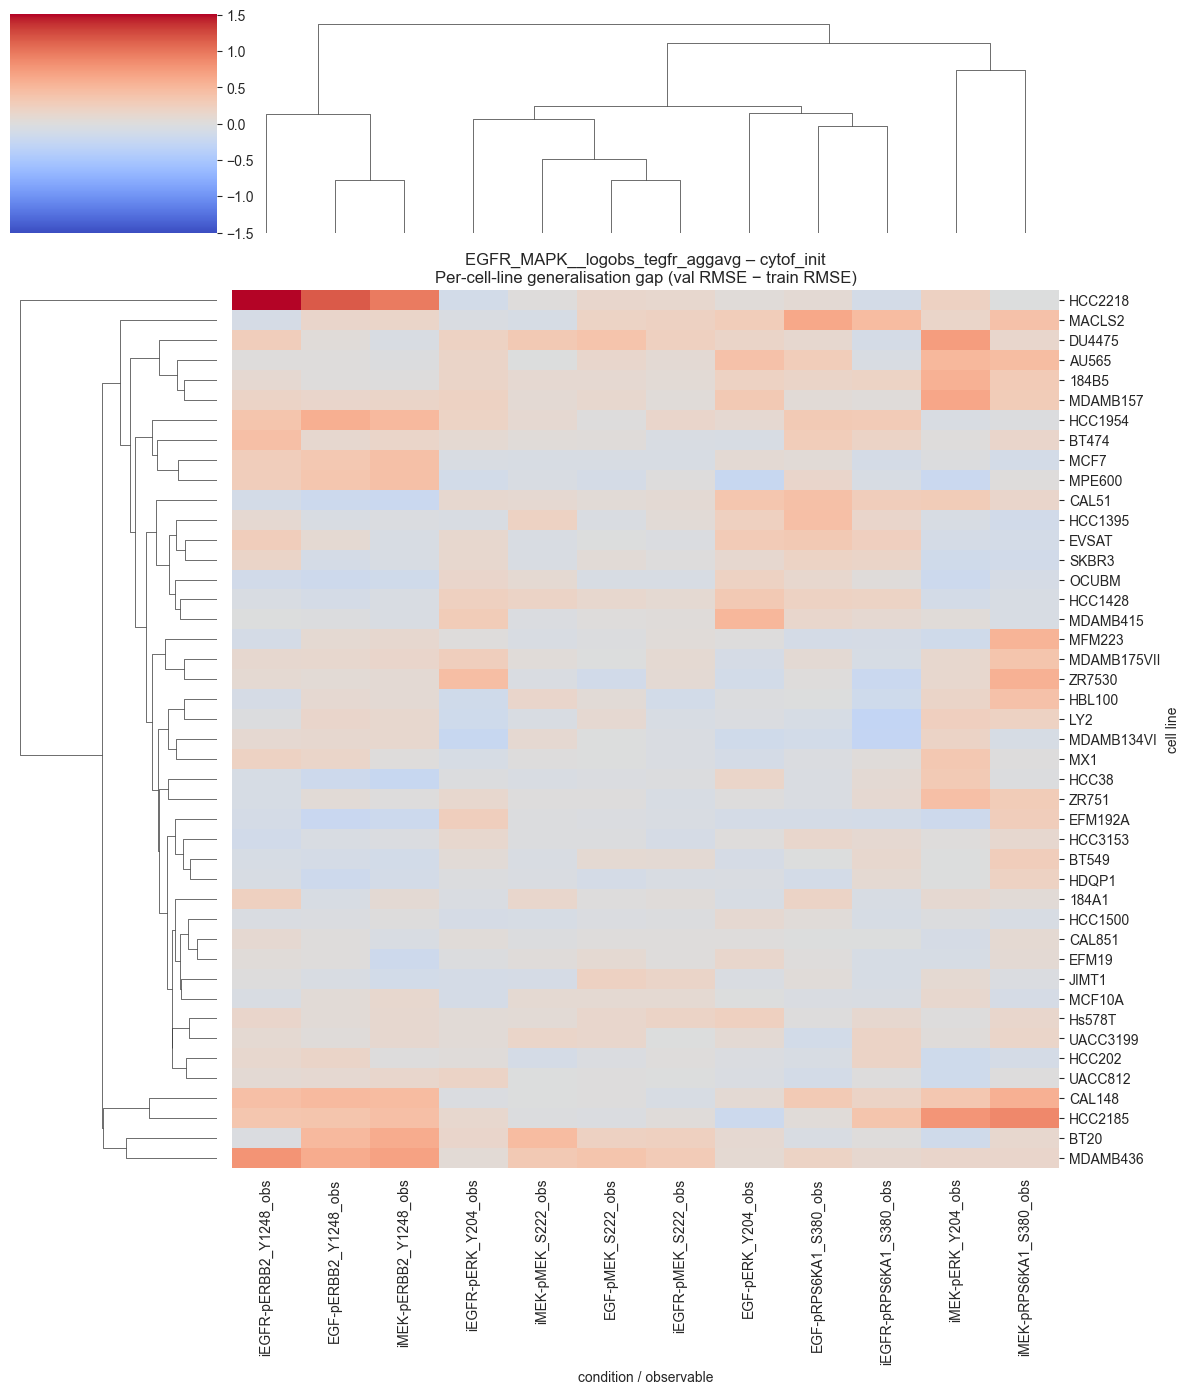

In [92]:
plot_residuals("EGFR_MAPK__logobs_tegfr_aggavg", context="cytof_init", have_her2=True)

# For noHER2, we can see a much clearer chunk of cell-lines now doing very poorly on ERBB2 observable in all conditions (left). Particularly if we subset to cell-lines that DO HAVE HER2 measurements